In [1]:
import pandas as pd
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')
print(df.shape)        
print(df.head())       
print(df.columns.tolist())  

(2823, 25)
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye   

In [2]:
print(df.dtypes)   # ORDERDATE  object görünəcək (mətn)
# Düzəltmə:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
# Yoxla:
print(df['ORDERDATE'].dtype)  #  datetime64 olmalıdır

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object
datetime64[us]


In [3]:
# Boş dəyərləri görür:
print(df.isnull().sum())
# Boşluqları doldurur:
df.fillna('Unknown', inplace=True)
# Dublikat yoxla:
print(f"Dublikat sətir: {df.duplicated().sum()}")
# 0 olmalıdır

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64
Dublikat sətir: 0


In [4]:
print(df.describe())  # SALES: min=482, max=14082, mean=3553
print(df['STATUS'].value_counts())     # Shipped: 92.6%
print(df['YEAR_ID'].value_counts())    # 2004: ən çox  1351
print(df['PRODUCTLINE'].value_counts()) # hansı məhsul daha çox

        ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count   2823.000000      2823.000000  2823.000000      2823.000000   
mean   10258.725115        35.092809    83.658544         6.466171   
min    10100.000000         6.000000    26.880000         1.000000   
25%    10180.000000        27.000000    68.860000         3.000000   
50%    10262.000000        35.000000    95.700000         6.000000   
75%    10333.500000        43.000000   100.000000         9.000000   
max    10425.000000        97.000000   100.000000        18.000000   
std       92.085478         9.741443    20.174277         4.225841   

              SALES                   ORDERDATE       QTR_ID     MONTH_ID  \
count   2823.000000                        2823  2823.000000  2823.000000   
mean    3553.889072  2004-05-11 00:16:49.989373     2.717676     7.092455   
min      482.130000         2003-01-06 00:00:00     1.000000     1.000000   
25%     2203.430000         2003-11-06 12:00:00     2.000000 

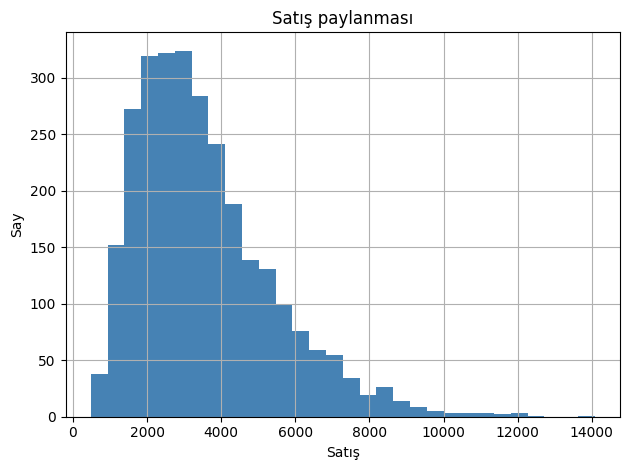

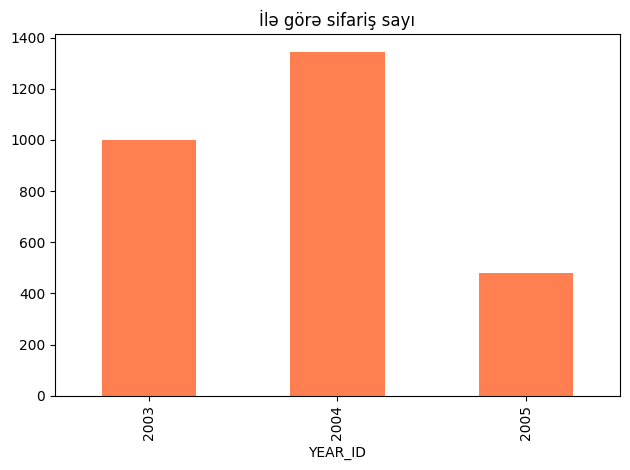

Fayl yadda saxlanıldı


In [5]:
import matplotlib.pyplot as plt

# 1) SALES histoqramı
df['SALES'].hist(bins=30, color='steelblue')
plt.title('Satış paylanması')
plt.xlabel('Satış')
plt.ylabel('Say')
plt.tight_layout()
plt.savefig('sales_histogram.png')
plt.show()

# 2) İlə görə sifariş sayı
df.groupby('YEAR_ID').size().plot(kind='bar', color='coral')
plt.title('İlə görə sifariş sayı')
plt.tight_layout()
plt.savefig('orders_by_year.png')
plt.show()

# ixrac hissesi
df.to_csv('sales_data_clean.csv', index=False)
print("Fayl yadda saxlanıldı")

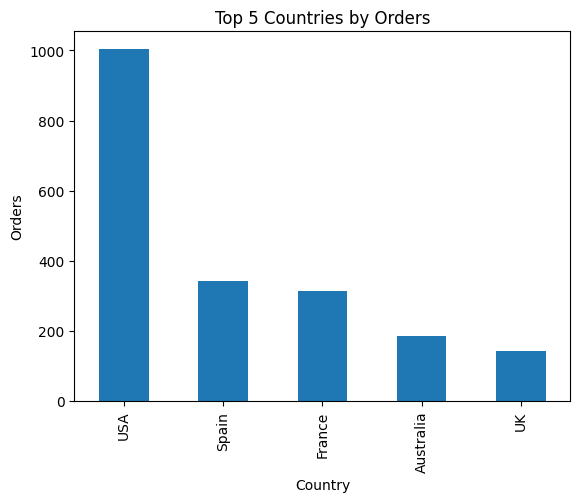

In [8]:
top_countries = df["COUNTRY"].value_counts().head(5)
plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 5 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Orders")
plt.show() #bonus